<a href="https://colab.research.google.com/github/zcleips/Advanced-CNN-Transfer-Learning/blob/main/Advanced_CNN_Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4


In [2]:
import os
import random
import time
import copy
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader, Subset

from torchvision import datasets, transforms, models
from torchvision.models import ResNet18_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Make experiments more reproducible
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Random seed:", SEED)

Random seed: 42


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [23]:
from torchvision.datasets import OxfordIIITPet
from torch.utils.data import ConcatDataset

DATA_DIR = "./data"

trainval_base = OxfordIIITPet(
    root=DATA_DIR,
    split="trainval",
    target_types="category",
    download=True
)

test_base = OxfordIIITPet(
    root=DATA_DIR,
    split="test",
    target_types="category",
    download=True
)

base_dataset = ConcatDataset([
    trainval_base,
    test_base
])

print("Total images:", len(base_dataset))
print("Number of classes:", len(trainval_base.classes))

Total images: 7349
Number of classes: 37


In [24]:
trainval_targets = np.array(trainval_base._labels)
test_targets = np.array(test_base._labels)

all_targets = np.concatenate([
    trainval_targets,
    test_targets
])

print("Total labels:", len(all_targets))

Total labels: 7349


In [25]:
class_to_idx = {
    cls: i for i, cls in enumerate(selected_classes)
}

original_class_to_idx = {
    cls: i for i, cls in enumerate(trainval_base.classes)
}

selected_original_indices = [
    original_class_to_idx[cls]
    for cls in selected_classes
]

print("Selected classes:")
for i, cls in enumerate(selected_classes):
    print(i, cls)

print("\nOriginal class indices:")
print(selected_original_indices)

Selected classes:
0 Abyssinian
1 Bengal
2 Birman
3 Persian
4 Siamese
5 American Bulldog
6 American Pit Bull Terrier
7 Basset Hound
8 Beagle
9 Bombay

Original class indices:
[0, 5, 6, 23, 32, 1, 2, 3, 4, 7]


In [26]:
selected_indices = np.where(
    np.isin(all_targets, selected_original_indices)
)[0]

print("Selected images:", len(selected_indices))

Selected images: 1981


In [27]:
from collections import Counter

selected_targets_original = all_targets[selected_indices]

class_counts = Counter(selected_targets_original)

print("Class distribution:\n")

for original_idx in selected_original_indices:
    count = class_counts[original_idx]
    class_name = trainval_base.classes[original_idx]
    print(f"{class_name:25s}: {count}")

Class distribution:

Abyssinian               : 198
Bengal                   : 200
Birman                   : 200
Persian                  : 200
Siamese                  : 199
American Bulldog         : 200
American Pit Bull Terrier: 200
Basset Hound             : 200
Beagle                   : 200
Bombay                   : 184


In [28]:
train_indices, temp_indices = train_test_split(
    selected_indices,
    test_size=0.30,
    random_state=SEED,
    stratify=selected_targets_original
)

temp_targets = all_targets[temp_indices]

val_indices, test_indices = train_test_split(
    temp_indices,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_targets
)

print("Train:", len(train_indices))
print("Validation:", len(val_indices))
print("Test:", len(test_indices))
print("Total:", len(train_indices) + len(val_indices) + len(test_indices))

Train: 1386
Validation: 297
Test: 298
Total: 1981


In [29]:
weights = models.ResNet18_Weights.IMAGENET1K_V1

mean = weights.transforms().mean
std = weights.transforms().std

# Training WITH augmentation
train_transform_aug = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# Training WITHOUT augmentation
train_transform_no_aug = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# Validation / Test
eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

print("Transforms ready.")

Transforms ready.


In [30]:
class PetSubset(Dataset):
    def __init__(self, base_dataset, indices, transform=None):
        self.base_dataset = base_dataset
        self.indices = list(indices)
        self.transform = transform

        self.original_to_new = {
            original_class_to_idx[cls]: new_idx
            for new_idx, cls in enumerate(selected_classes)
        }

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]

        image, original_label = self.base_dataset[real_idx]

        if self.transform:
            image = self.transform(image)

        label = self.original_to_new[original_label]

        return image, label

In [31]:
train_dataset = PetSubset(
    base_dataset,
    train_indices,
    transform=train_transform_aug
)

val_dataset = PetSubset(
    base_dataset,
    val_indices,
    transform=eval_transform
)

test_dataset = PetSubset(
    base_dataset,
    test_indices,
    transform=eval_transform
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 1386
Validation: 297
Test: 298


In [32]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders ready.")

DataLoaders ready.


In [33]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("First 10 labels:", labels[:10])

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
First 10 labels: tensor([3, 6, 6, 4, 7, 5, 5, 9, 8, 4])


In [34]:
print("Unique labels in batch:", torch.unique(labels).tolist())

Unique labels in batch: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [35]:
# B1: ResNet-18

model_b1 = models.resnet18(weights=None)

num_features = model_b1.fc.in_features
model_b1.fc = nn.Linear(num_features, 10)

model_b1 = model_b1.to(device)

print(model_b1.fc)

Linear(in_features=512, out_features=10, bias=True)


In [36]:
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )
    return total, trainable


total_params, trainable_params = count_parameters(model_b1)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters:     11,181,642
Trainable parameters: 11,181,642


In [37]:
criterion = nn.CrossEntropyLoss()

optimizer_b1 = optim.AdamW(
    model_b1.parameters(),
    lr=1e-3,
    weight_decay=1e-2
)

print("Optimizer:", optimizer_b1)
print("Learning rate:", 1e-3)

Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.01
)
Learning rate: 0.001


In [38]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [39]:
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return (
        epoch_loss,
        epoch_accuracy,
        np.array(all_labels),
        np.array(all_predictions)
    )

In [40]:
MAX_EPOCHS = 20
PATIENCE = 4

history_b1 = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_val_loss = float("inf")
best_model_state = None
epochs_without_improvement = 0

start_time = time.time()

for epoch in range(MAX_EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model_b1,
        train_loader,
        criterion,
        optimizer_b1,
        device
    )

    val_loss, val_acc, _, _ = evaluate(
        model_b1,
        val_loader,
        criterion,
        device
    )

    # Save history
    history_b1["train_loss"].append(train_loss)
    history_b1["train_accuracy"].append(train_acc)
    history_b1["val_loss"].append(val_loss)
    history_b1["val_accuracy"].append(val_acc)

    print(
        f"Epoch {epoch+1:02d}/{MAX_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss

        best_model_state = copy.deepcopy(
            model_b1.state_dict()
        )

        epochs_without_improvement = 0

    else:
        epochs_without_improvement += 1

        if epochs_without_improvement >= PATIENCE:
            print(
                f"\nEarly stopping triggered at epoch {epoch+1}."
            )
            break

training_time_b1 = time.time() - start_time

# Restore best model
model_b1.load_state_dict(best_model_state)

print(f"\nTraining time: {training_time_b1:.2f} seconds")
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Epochs trained: {len(history_b1['train_loss'])}")

Epoch 01/20 | Train Loss: 2.3656 | Train Acc: 0.1616 | Val Loss: 2.3975 | Val Acc: 0.2222
Epoch 02/20 | Train Loss: 2.0314 | Train Acc: 0.2742 | Val Loss: 2.4326 | Val Acc: 0.2626
Epoch 03/20 | Train Loss: 1.9278 | Train Acc: 0.2987 | Val Loss: 1.9682 | Val Acc: 0.2929
Epoch 04/20 | Train Loss: 1.8041 | Train Acc: 0.3434 | Val Loss: 1.8850 | Val Acc: 0.3468
Epoch 05/20 | Train Loss: 1.7108 | Train Acc: 0.3766 | Val Loss: 1.8276 | Val Acc: 0.3603
Epoch 06/20 | Train Loss: 1.7088 | Train Acc: 0.3730 | Val Loss: 1.6697 | Val Acc: 0.3872
Epoch 07/20 | Train Loss: 1.6298 | Train Acc: 0.4127 | Val Loss: 1.5811 | Val Acc: 0.4175
Epoch 08/20 | Train Loss: 1.5206 | Train Acc: 0.4668 | Val Loss: 1.9219 | Val Acc: 0.3603
Epoch 09/20 | Train Loss: 1.4804 | Train Acc: 0.4704 | Val Loss: 2.1378 | Val Acc: 0.3367
Epoch 10/20 | Train Loss: 1.4743 | Train Acc: 0.4704 | Val Loss: 1.5577 | Val Acc: 0.4411
Epoch 11/20 | Train Loss: 1.4358 | Train Acc: 0.4704 | Val Loss: 1.8334 | Val Acc: 0.3603
Epoch 12/2

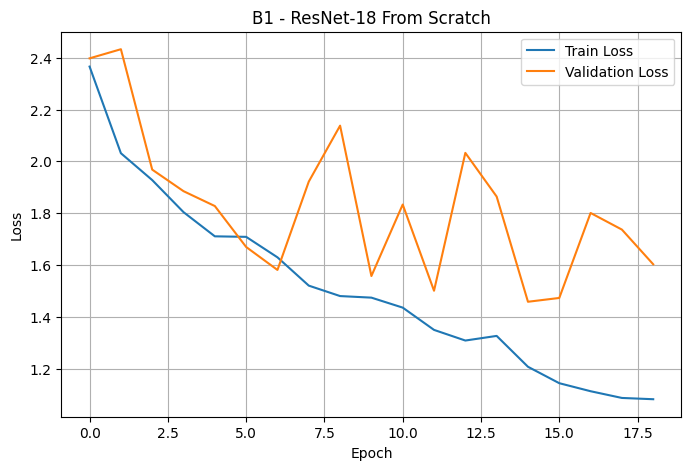

In [41]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_b1["train_loss"],
    label="Train Loss"
)

plt.plot(
    history_b1["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("B1 - ResNet-18 From Scratch")
plt.legend()
plt.grid(True)

plt.show()

In [42]:
test_loss_b1, test_acc_b1, y_true_b1, y_pred_b1 = evaluate(
    model_b1,
    test_loader,
    criterion,
    device
)

test_f1_b1 = f1_score(
    y_true_b1,
    y_pred_b1,
    average="macro"
)

print(f"Test Loss:     {test_loss_b1:.4f}")
print(f"Test Accuracy: {test_acc_b1:.4f}")
print(f"Test Macro F1: {test_f1_b1:.4f}")

Test Loss:     1.5940
Test Accuracy: 0.4732
Test Macro F1: 0.4644


In [43]:
results = []

results.append({
    "experiment": "B1",
    "strategy": "From Scratch",
    "trainable_parameters": trainable_params,
    "learning_rate": 1e-3,
    "epochs": len(history_b1["train_loss"]),
    "training_time_seconds": training_time_b1,
    "best_val_loss": best_val_loss,
    "final_val_accuracy": history_b1["val_accuracy"][-1],
    "test_accuracy": test_acc_b1,
    "test_macro_f1": test_f1_b1
})

results_df = pd.DataFrame(results)

results_df

,experiment,strategy,trainable_parameters,learning_rate,epochs,training_time_seconds,best_val_loss,final_val_accuracy,test_accuracy,test_macro_f1
0,B1,From Scratch,11181642,0.001,19,274.35787,1.45841,0.474747,0.473154,0.464425


In [44]:
# Feature Extraction
weights = models.ResNet18_Weights.IMAGENET1K_V1

model_b2 = models.resnet18(weights=weights)

for param in model_b2.parameters():
    param.requires_grad = False

num_features = model_b2.fc.in_features

model_b2.fc = nn.Linear(
    num_features,
    10
)

model_b2 = model_b2.to(device)

print(model_b2.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 37.7MB/s]


Linear(in_features=512, out_features=10, bias=True)


In [45]:
total_params_b2, trainable_params_b2 = count_parameters(model_b2)

print(f"Total parameters:     {total_params_b2:,}")
print(f"Trainable parameters: {trainable_params_b2:,}")

Total parameters:     11,181,642
Trainable parameters: 5,130


In [46]:
criterion_b2 = nn.CrossEntropyLoss()

optimizer_b2 = optim.AdamW(
    model_b2.fc.parameters(),
    lr=1e-3,
    weight_decay=1e-2
)

print("B2 optimizer ready.")
print("Learning rate:", 1e-3)

B2 optimizer ready.
Learning rate: 0.001


In [47]:
MAX_EPOCHS = 20
PATIENCE = 4

history_b2 = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_val_loss_b2 = float("inf")
best_model_state_b2 = None
epochs_without_improvement = 0

start_time = time.time()

for epoch in range(MAX_EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model_b2,
        train_loader,
        criterion_b2,
        optimizer_b2,
        device
    )

    val_loss, val_acc, _, _ = evaluate(
        model_b2,
        val_loader,
        criterion_b2,
        device
    )

    history_b2["train_loss"].append(train_loss)
    history_b2["train_accuracy"].append(train_acc)
    history_b2["val_loss"].append(val_loss)
    history_b2["val_accuracy"].append(val_acc)

    print(
        f"Epoch {epoch+1:02d}/{MAX_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    if val_loss < best_val_loss_b2:

        best_val_loss_b2 = val_loss

        best_model_state_b2 = copy.deepcopy(
            model_b2.state_dict()
        )

        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1

        if epochs_without_improvement >= PATIENCE:
            print(
                f"\nEarly stopping triggered at epoch {epoch+1}."
            )
            break

training_time_b2 = time.time() - start_time

# Restore best validation model
model_b2.load_state_dict(best_model_state_b2)

print(f"\nTraining time: {training_time_b2:.2f} seconds")
print(f"Best validation loss: {best_val_loss_b2:.4f}")
print(f"Epochs trained: {len(history_b2['train_loss'])}")

Epoch 01/20 | Train Loss: 1.4932 | Train Acc: 0.5332 | Val Loss: 0.8263 | Val Acc: 0.7609
Epoch 02/20 | Train Loss: 0.7112 | Train Acc: 0.8377 | Val Loss: 0.4750 | Val Acc: 0.8956
Epoch 03/20 | Train Loss: 0.5176 | Train Acc: 0.8709 | Val Loss: 0.3635 | Val Acc: 0.9024
Epoch 04/20 | Train Loss: 0.4252 | Train Acc: 0.8903 | Val Loss: 0.3070 | Val Acc: 0.9226
Epoch 05/20 | Train Loss: 0.3645 | Train Acc: 0.9113 | Val Loss: 0.2811 | Val Acc: 0.9259
Epoch 06/20 | Train Loss: 0.3437 | Train Acc: 0.9127 | Val Loss: 0.2649 | Val Acc: 0.9226
Epoch 07/20 | Train Loss: 0.3200 | Train Acc: 0.9084 | Val Loss: 0.2550 | Val Acc: 0.9259
Epoch 08/20 | Train Loss: 0.2734 | Train Acc: 0.9358 | Val Loss: 0.2161 | Val Acc: 0.9327
Epoch 09/20 | Train Loss: 0.2978 | Train Acc: 0.9040 | Val Loss: 0.2329 | Val Acc: 0.9226
Epoch 10/20 | Train Loss: 0.2679 | Train Acc: 0.9257 | Val Loss: 0.2355 | Val Acc: 0.9158
Epoch 11/20 | Train Loss: 0.2582 | Train Acc: 0.9293 | Val Loss: 0.2079 | Val Acc: 0.9394
Epoch 12/2

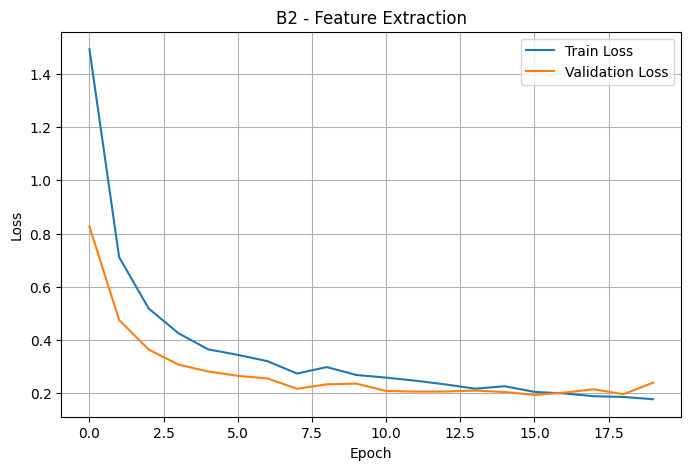

In [48]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_b2["train_loss"],
    label="Train Loss"
)

plt.plot(
    history_b2["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("B2 - Feature Extraction")
plt.legend()
plt.grid(True)

plt.show()

In [49]:
test_loss_b2, test_acc_b2, y_true_b2, y_pred_b2 = evaluate(
    model_b2,
    test_loader,
    criterion_b2,
    device
)

test_f1_b2 = f1_score(
    y_true_b2,
    y_pred_b2,
    average="macro"
)

print(f"Test Loss:     {test_loss_b2:.4f}")
print(f"Test Accuracy: {test_acc_b2:.4f}")
print(f"Test Macro F1: {test_f1_b2:.4f}")

Test Loss:     0.1744
Test Accuracy: 0.9396
Test Macro F1: 0.9404


In [50]:
results.append({
    "experiment": "B2",
    "strategy": "Feature Extraction",
    "trainable_parameters": trainable_params_b2,
    "learning_rate": 1e-3,
    "epochs": len(history_b2["train_loss"]),
    "training_time_seconds": training_time_b2,
    "best_val_loss": best_val_loss_b2,
    "final_val_accuracy": history_b2["val_accuracy"][-1],
    "test_accuracy": test_acc_b2,
    "test_macro_f1": test_f1_b2
})

results_df = pd.DataFrame(results)

results_df

,experiment,strategy,trainable_parameters,learning_rate,epochs,training_time_seconds,best_val_loss,final_val_accuracy,test_accuracy,test_macro_f1
0,B1,From Scratch,11181642,0.001,19,274.357870,1.458410,0.474747,0.473154,0.464425
1,B2,Feature Extraction,5130,0.001,20,267.590178,0.193068,0.919192,0.939597,0.940377


In [51]:
# B3: Progressive Fine-Tuning

weights = models.ResNet18_Weights.IMAGENET1K_V1

model_b3 = models.resnet18(weights=weights)

# Freeze
for param in model_b3.parameters():
    param.requires_grad = False

# Replace classifier
num_features = model_b3.fc.in_features

model_b3.fc = nn.Linear(
    num_features,
    10
)

# Unfreeze the final residual block
for param in model_b3.layer4.parameters():
    param.requires_grad = True

model_b3 = model_b3.to(device)

print("B3 model ready.")

B3 model ready.


In [52]:
for name, param in model_b3.named_parameters():
    if param.requires_grad:
        print(name)

layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.weight
layer4.0.bn2.weight
layer4.0.bn2.bias
layer4.0.downsample.0.weight
layer4.0.downsample.1.weight
layer4.0.downsample.1.bias
layer4.1.conv1.weight
layer4.1.bn1.weight
layer4.1.bn1.bias
layer4.1.conv2.weight
layer4.1.bn2.weight
layer4.1.bn2.bias
fc.weight
fc.bias


In [53]:
total_params_b3, trainable_params_b3 = count_parameters(model_b3)

print(f"Total parameters:     {total_params_b3:,}")
print(f"Trainable parameters: {trainable_params_b3:,}")

Total parameters:     11,181,642
Trainable parameters: 8,398,858


In [54]:
criterion_b3 = nn.CrossEntropyLoss()

optimizer_b3 = optim.AdamW(
    [
        {
            "params": model_b3.layer4.parameters(),
            "lr": 1e-4
        },
        {
            "params": model_b3.fc.parameters(),
            "lr": 1e-3
        }
    ],
    weight_decay=1e-2
)

print("B3 optimizer ready.")
print("layer4 learning rate: 1e-4")
print("fc learning rate:     1e-3")

B3 optimizer ready.
layer4 learning rate: 1e-4
fc learning rate:     1e-3


In [55]:
MAX_EPOCHS = 20
PATIENCE = 4

history_b3 = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_val_loss_b3 = float("inf")
best_model_state_b3 = None
epochs_without_improvement = 0

start_time = time.time()

for epoch in range(MAX_EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model_b3,
        train_loader,
        criterion_b3,
        optimizer_b3,
        device
    )

    val_loss, val_acc, _, _ = evaluate(
        model_b3,
        val_loader,
        criterion_b3,
        device
    )

    history_b3["train_loss"].append(train_loss)
    history_b3["train_accuracy"].append(train_acc)
    history_b3["val_loss"].append(val_loss)
    history_b3["val_accuracy"].append(val_acc)

    print(
        f"Epoch {epoch+1:02d}/{MAX_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    if val_loss < best_val_loss_b3:

        best_val_loss_b3 = val_loss

        best_model_state_b3 = copy.deepcopy(
            model_b3.state_dict()
        )

        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1

        if epochs_without_improvement >= PATIENCE:
            print(
                f"\nEarly stopping triggered at epoch {epoch+1}."
            )
            break

training_time_b3 = time.time() - start_time

# Restore best validation model
model_b3.load_state_dict(best_model_state_b3)

print(f"\nTraining time: {training_time_b3:.2f} seconds")
print(f"Best validation loss: {best_val_loss_b3:.4f}")
print(f"Epochs trained: {len(history_b3['train_loss'])}")

Epoch 01/20 | Train Loss: 0.8823 | Train Acc: 0.7266 | Val Loss: 0.2494 | Val Acc: 0.9226
Epoch 02/20 | Train Loss: 0.2521 | Train Acc: 0.9257 | Val Loss: 0.2026 | Val Acc: 0.9293
Epoch 03/20 | Train Loss: 0.1475 | Train Acc: 0.9589 | Val Loss: 0.2417 | Val Acc: 0.9091
Epoch 04/20 | Train Loss: 0.0963 | Train Acc: 0.9726 | Val Loss: 0.2283 | Val Acc: 0.9259
Epoch 05/20 | Train Loss: 0.0672 | Train Acc: 0.9812 | Val Loss: 0.1736 | Val Acc: 0.9192
Epoch 06/20 | Train Loss: 0.0631 | Train Acc: 0.9827 | Val Loss: 0.2311 | Val Acc: 0.9293
Epoch 07/20 | Train Loss: 0.0533 | Train Acc: 0.9899 | Val Loss: 0.1689 | Val Acc: 0.9293
Epoch 08/20 | Train Loss: 0.0414 | Train Acc: 0.9899 | Val Loss: 0.2498 | Val Acc: 0.9226
Epoch 09/20 | Train Loss: 0.0491 | Train Acc: 0.9834 | Val Loss: 0.2385 | Val Acc: 0.9125
Epoch 10/20 | Train Loss: 0.0425 | Train Acc: 0.9885 | Val Loss: 0.1969 | Val Acc: 0.9327
Epoch 11/20 | Train Loss: 0.0240 | Train Acc: 0.9928 | Val Loss: 0.2182 | Val Acc: 0.9394

Early sto

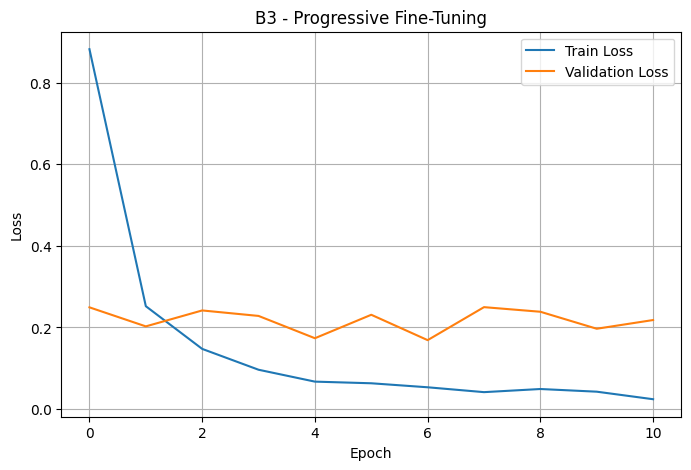

In [56]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_b3["train_loss"],
    label="Train Loss"
)

plt.plot(
    history_b3["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("B3 - Progressive Fine-Tuning")
plt.legend()
plt.grid(True)

plt.show()

In [57]:
test_loss_b3, test_acc_b3, y_true_b3, y_pred_b3 = evaluate(
    model_b3,
    test_loader,
    criterion_b3,
    device
)

test_f1_b3 = f1_score(
    y_true_b3,
    y_pred_b3,
    average="macro"
)

print(f"Test Loss:     {test_loss_b3:.4f}")
print(f"Test Accuracy: {test_acc_b3:.4f}")
print(f"Test Macro F1: {test_f1_b3:.4f}")

Test Loss:     0.1241
Test Accuracy: 0.9564
Test Macro F1: 0.9565


In [58]:
results.append({
    "experiment": "B3",
    "strategy": "Progressive Fine-Tuning",
    "trainable_parameters": trainable_params_b3,
    "learning_rate": "layer4=1e-4, fc=1e-3",
    "epochs": len(history_b3["train_loss"]),
    "training_time_seconds": training_time_b3,
    "best_val_loss": best_val_loss_b3,
    "final_val_accuracy": history_b3["val_accuracy"][-1],
    "test_accuracy": test_acc_b3,
    "test_macro_f1": test_f1_b3
})

results_df = pd.DataFrame(results)

results_df

,experiment,strategy,trainable_parameters,learning_rate,epochs,training_time_seconds,best_val_loss,final_val_accuracy,test_accuracy,test_macro_f1
0,B1,From Scratch,11181642,0.001,19,274.357870,1.458410,0.474747,0.473154,0.464425
1,B2,Feature Extraction,5130,0.001,20,267.590178,0.193068,0.919192,0.939597,0.940377
2,B3,Progressive Fine-Tuning,8398858,"layer4=1e-4, fc=1e-3",11,149.276237,0.168916,0.939394,0.956376,0.956543


In [59]:
train_dataset_no_aug = PetSubset(
    base_dataset,
    train_indices,
    transform=train_transform_no_aug
)

print("Training images:", len(train_dataset_no_aug))

Training images: 1386


In [60]:
train_loader_no_aug = DataLoader(
    train_dataset_no_aug,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print("Non-augmented DataLoader ready.")

Non-augmented DataLoader ready.


In [61]:
weights = models.ResNet18_Weights.IMAGENET1K_V1

model_b4 = models.resnet18(weights=weights)

# Freeze
for param in model_b4.parameters():
    param.requires_grad = False

# Replace classifier
num_features = model_b4.fc.in_features

model_b4.fc = nn.Linear(
    num_features,
    10
)

# Unfreeze layer4
for param in model_b4.layer4.parameters():
    param.requires_grad = True

model_b4 = model_b4.to(device)

print("B4 model ready.")

B4 model ready.


In [62]:
total_params_b4, trainable_params_b4 = count_parameters(model_b4)

print(f"Total parameters:     {total_params_b4:,}")
print(f"Trainable parameters: {trainable_params_b4:,}")

Total parameters:     11,181,642
Trainable parameters: 8,398,858


In [63]:
criterion_b4 = nn.CrossEntropyLoss()

optimizer_b4 = optim.AdamW(
    [
        {
            "params": model_b4.layer4.parameters(),
            "lr": 1e-4
        },
        {
            "params": model_b4.fc.parameters(),
            "lr": 1e-3
        }
    ],
    weight_decay=1e-2
)

print("B4 optimizer ready.")

B4 optimizer ready.


In [64]:
MAX_EPOCHS = 20
PATIENCE = 4

history_b4 = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_val_loss_b4 = float("inf")
best_model_state_b4 = None
epochs_without_improvement = 0

start_time = time.time()

for epoch in range(MAX_EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model_b4,
        train_loader_no_aug,
        criterion_b4,
        optimizer_b4,
        device
    )

    val_loss, val_acc, _, _ = evaluate(
        model_b4,
        val_loader,
        criterion_b4,
        device
    )

    history_b4["train_loss"].append(train_loss)
    history_b4["train_accuracy"].append(train_acc)
    history_b4["val_loss"].append(val_loss)
    history_b4["val_accuracy"].append(val_acc)

    print(
        f"Epoch {epoch+1:02d}/{MAX_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    if val_loss < best_val_loss_b4:

        best_val_loss_b4 = val_loss

        best_model_state_b4 = copy.deepcopy(
            model_b4.state_dict()
        )

        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1

        if epochs_without_improvement >= PATIENCE:
            print(
                f"\nEarly stopping triggered at epoch {epoch+1}."
            )
            break

training_time_b4 = time.time() - start_time

model_b4.load_state_dict(best_model_state_b4)

print(f"\nTraining time: {training_time_b4:.2f} seconds")
print(f"Best validation loss: {best_val_loss_b4:.4f}")
print(f"Epochs trained: {len(history_b4['train_loss'])}")

Epoch 01/20 | Train Loss: 0.7740 | Train Acc: 0.7626 | Val Loss: 0.2347 | Val Acc: 0.9226
Epoch 02/20 | Train Loss: 0.1214 | Train Acc: 0.9791 | Val Loss: 0.1908 | Val Acc: 0.9327
Epoch 03/20 | Train Loss: 0.0464 | Train Acc: 0.9964 | Val Loss: 0.2245 | Val Acc: 0.9327
Epoch 04/20 | Train Loss: 0.0283 | Train Acc: 0.9971 | Val Loss: 0.1778 | Val Acc: 0.9461
Epoch 05/20 | Train Loss: 0.0137 | Train Acc: 1.0000 | Val Loss: 0.1937 | Val Acc: 0.9360
Epoch 06/20 | Train Loss: 0.0097 | Train Acc: 0.9993 | Val Loss: 0.2002 | Val Acc: 0.9428
Epoch 07/20 | Train Loss: 0.0159 | Train Acc: 0.9964 | Val Loss: 0.2072 | Val Acc: 0.9461
Epoch 08/20 | Train Loss: 0.0043 | Train Acc: 1.0000 | Val Loss: 0.2085 | Val Acc: 0.9529

Early stopping triggered at epoch 8.

Training time: 74.25 seconds
Best validation loss: 0.1778
Epochs trained: 8


In [65]:
test_loss_b4, test_acc_b4, y_true_b4, y_pred_b4 = evaluate(
    model_b4,
    test_loader,
    criterion_b4,
    device
)

test_f1_b4 = f1_score(
    y_true_b4,
    y_pred_b4,
    average="macro"
)

print(f"Test Loss:     {test_loss_b4:.4f}")
print(f"Test Accuracy: {test_acc_b4:.4f}")
print(f"Test Macro F1: {test_f1_b4:.4f}")

Test Loss:     0.1216
Test Accuracy: 0.9530
Test Macro F1: 0.9533


In [66]:
results.append({
    "experiment": "B4",
    "strategy": "B3 Fine-Tuning - No Augmentation",
    "trainable_parameters": trainable_params_b4,
    "learning_rate": "layer4=1e-4, fc=1e-3",
    "epochs": len(history_b4["train_loss"]),
    "training_time_seconds": training_time_b4,
    "best_val_loss": best_val_loss_b4,
    "final_val_accuracy": history_b4["val_accuracy"][-1],
    "test_accuracy": test_acc_b4,
    "test_macro_f1": test_f1_b4
})

results_df = pd.DataFrame(results)

results_df

,experiment,strategy,trainable_parameters,learning_rate,epochs,training_time_seconds,best_val_loss,final_val_accuracy,test_accuracy,test_macro_f1
0,B1,From Scratch,11181642,0.001,19,274.357870,1.458410,0.474747,0.473154,0.464425
1,B2,Feature Extraction,5130,0.001,20,267.590178,0.193068,0.919192,0.939597,0.940377
2,B3,Progressive Fine-Tuning,8398858,"layer4=1e-4, fc=1e-3",11,149.276237,0.168916,0.939394,0.956376,0.956543
3,B4,B3 Fine-Tuning - No Augmentation,8398858,"layer4=1e-4, fc=1e-3",8,74.253400,0.177792,0.952862,0.953020,0.953313


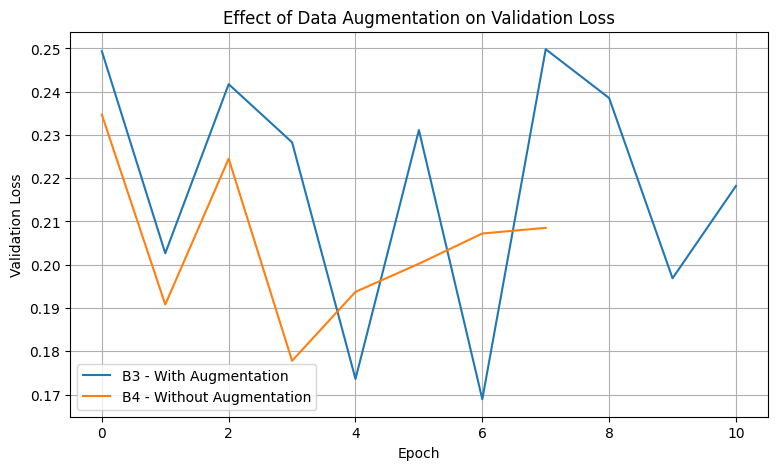

In [67]:
plt.figure(figsize=(9, 5))

plt.plot(
    history_b3["val_loss"],
    label="B3 - With Augmentation"
)

plt.plot(
    history_b4["val_loss"],
    label="B4 - Without Augmentation"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Effect of Data Augmentation on Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

<Figure size 1000x1000 with 0 Axes>

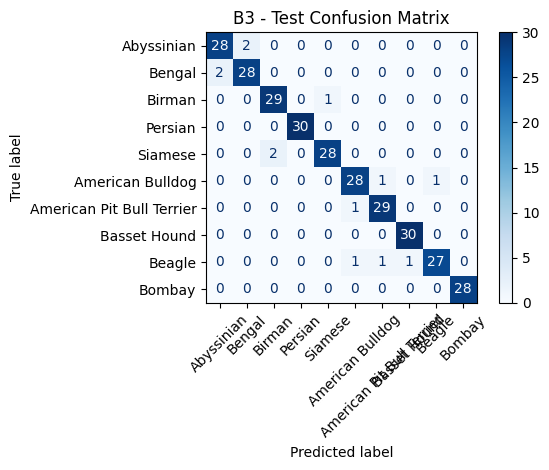

In [68]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get B3 predictions on test set
test_loss_b3, test_acc_b3, y_true_b3, y_pred_b3 = evaluate(
    model_b3,
    test_loader,
    criterion_b3,
    device
)

cm = confusion_matrix(
    y_true_b3,
    y_pred_b3
)

plt.figure(figsize=(10, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=selected_classes
)

disp.plot(
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("B3 - Test Confusion Matrix")
plt.tight_layout()
plt.show()

In [69]:
confusions = []

for actual in range(len(selected_classes)):
    for predicted in range(len(selected_classes)):

        if actual != predicted and cm[actual, predicted] > 0:
            confusions.append({
                "actual": selected_classes[actual],
                "predicted": selected_classes[predicted],
                "count": cm[actual, predicted]
            })

confusions_df = pd.DataFrame(confusions)

confusions_df = confusions_df.sort_values(
    "count",
    ascending=False
)

confusions_df.head(10)

,actual,predicted,count
0,Abyssinian,Bengal,2
1,Bengal,Abyssinian,2
3,Siamese,Birman,2
2,Birman,Siamese,1
4,American Bulldog,American Pit Bull Terrier,1
5,American Bulldog,Beagle,1
6,American Pit Bull Terrier,American Bulldog,1
7,Beagle,American Bulldog,1
8,Beagle,American Pit Bull Terrier,1
9,Beagle,Basset Hound,1


In [70]:
def get_misclassified_examples(
    model,
    loader,
    dataset,
    device,
    num_examples=8
):
    model.eval()

    mistakes = []

    current_position = 0

    with torch.no_grad():

        for images, labels in loader:

            images_device = images.to(device)

            outputs = model(images_device)

            probabilities = torch.softmax(
                outputs,
                dim=1
            )

            confidences, predictions = probabilities.max(dim=1)

            for i in range(len(labels)):

                actual = labels[i].item()
                predicted = predictions[i].item()
                confidence = confidences[i].item()

                if actual != predicted:

                    mistakes.append({
                        "dataset_index": current_position + i,
                        "actual": actual,
                        "predicted": predicted,
                        "confidence": confidence,
                        "image": images[i].cpu()
                    })

            current_position += len(labels)

    # Highest-confidence mistakes first
    mistakes.sort(
        key=lambda x: x["confidence"],
        reverse=True
    )

    return mistakes[:num_examples]

In [71]:
mistakes_b3 = get_misclassified_examples(
    model_b3,
    test_loader,
    test_dataset,
    device,
    num_examples=8
)

for i, mistake in enumerate(mistakes_b3):

    print(
        f"{i+1}. "
        f"Actual: {selected_classes[mistake['actual']]} | "
        f"Predicted: {selected_classes[mistake['predicted']]} | "
        f"Confidence: {mistake['confidence']:.2%}"
    )

1. Actual: Bengal | Predicted: Abyssinian | Confidence: 99.79%
2. Actual: Siamese | Predicted: Birman | Confidence: 95.29%
3. Actual: Abyssinian | Predicted: Bengal | Confidence: 88.50%
4. Actual: American Bulldog | Predicted: American Pit Bull Terrier | Confidence: 80.11%
5. Actual: Bengal | Predicted: Abyssinian | Confidence: 80.03%
6. Actual: Siamese | Predicted: Birman | Confidence: 78.86%
7. Actual: Birman | Predicted: Siamese | Confidence: 77.17%
8. Actual: Beagle | Predicted: Basset Hound | Confidence: 74.25%


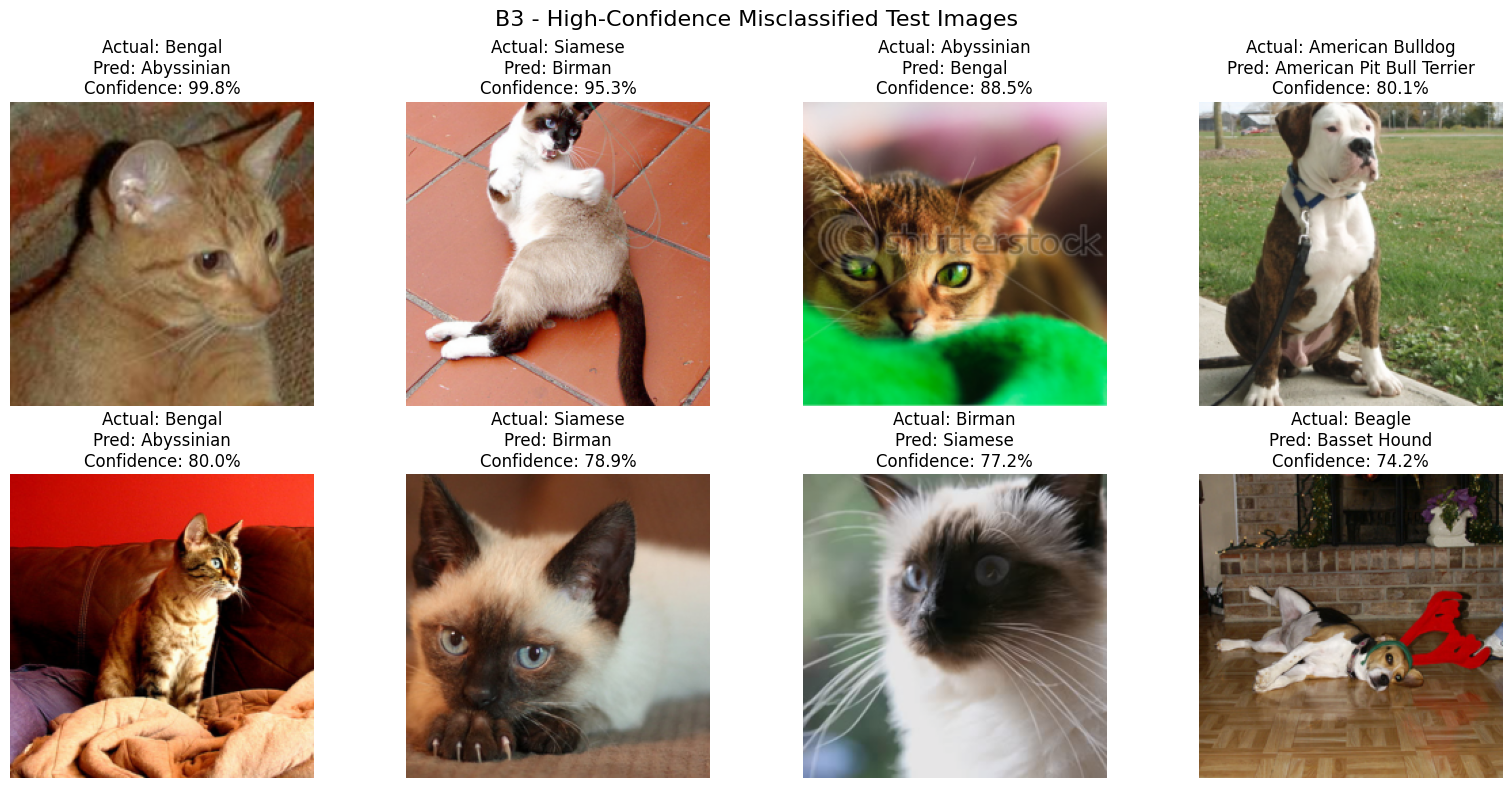

In [72]:
fig, axes = plt.subplots(
    2,
    4,
    figsize=(16, 8)
)

for ax, mistake in zip(
    axes.flatten(),
    mistakes_b3
):

    image = mistake["image"]

    # Undo ImageNet normalization
    image = image.permute(1, 2, 0).numpy()

    image = image * np.array(std) + np.array(mean)

    image = np.clip(image, 0, 1)

    ax.imshow(image)

    ax.set_title(
        f"Actual: {selected_classes[mistake['actual']]}\n"
        f"Pred: {selected_classes[mistake['predicted']]}\n"
        f"Confidence: {mistake['confidence']:.1%}"
    )

    ax.axis("off")

plt.suptitle(
    "B3 - High-Confidence Misclassified Test Images",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [73]:
final_results = results_df[
    [
        "experiment",
        "strategy",
        "trainable_parameters",
        "epochs",
        "training_time_seconds",
        "best_val_loss",
        "test_accuracy",
        "test_macro_f1"
    ]
].copy()

final_results["test_accuracy"] *= 100
final_results["test_macro_f1"] *= 100

final_results["test_accuracy"] = final_results["test_accuracy"].round(2)
final_results["test_macro_f1"] = final_results["test_macro_f1"].round(2)

final_results["training_time_seconds"] = (
    final_results["training_time_seconds"].round(2)
)

final_results["best_val_loss"] = (
    final_results["best_val_loss"].round(4)
)

final_results

,experiment,strategy,trainable_parameters,epochs,training_time_seconds,best_val_loss,test_accuracy,test_macro_f1
0,B1,From Scratch,11181642,19,274.36,1.4584,47.32,46.44
1,B2,Feature Extraction,5130,20,267.59,0.1931,93.96,94.04
2,B3,Progressive Fine-Tuning,8398858,11,149.28,0.1689,95.64,95.65
3,B4,B3 Fine-Tuning - No Augmentation,8398858,8,74.25,0.1778,95.30,95.33


In [74]:
b1_acc = results_df.loc[
    results_df["experiment"] == "B1",
    "test_accuracy"
].iloc[0]

b2_acc = results_df.loc[
    results_df["experiment"] == "B2",
    "test_accuracy"
].iloc[0]

b3_acc = results_df.loc[
    results_df["experiment"] == "B3",
    "test_accuracy"
].iloc[0]

b4_acc = results_df.loc[
    results_df["experiment"] == "B4",
    "test_accuracy"
].iloc[0]

print(f"B1 → B2: {(b2_acc - b1_acc) * 100:.2f} percentage points")
print(f"B2 → B3: {(b3_acc - b2_acc) * 100:.2f} percentage points")
print(f"B3 → B4: {(b4_acc - b3_acc) * 100:.2f} percentage points")

B1 → B2: 46.64 percentage points
B2 → B3: 1.68 percentage points
B3 → B4: -0.34 percentage points


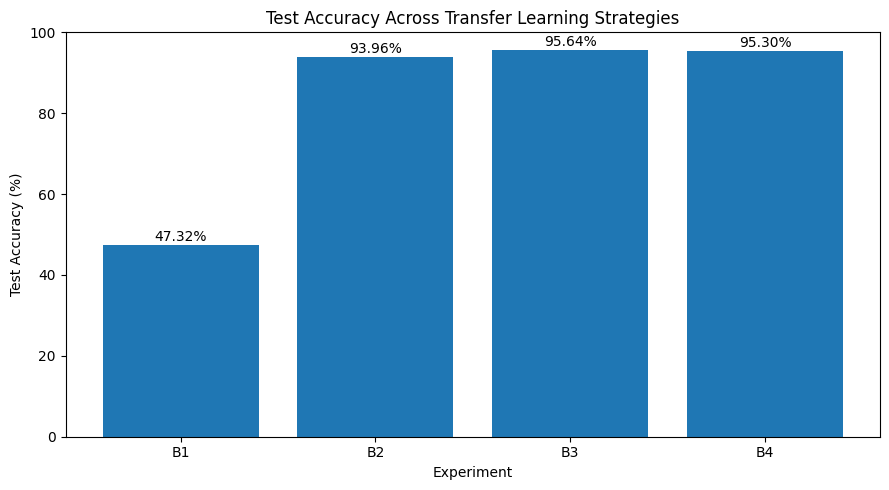

In [75]:
plt.figure(figsize=(9, 5))

plt.bar(
    final_results["experiment"],
    final_results["test_accuracy"]
)

plt.xlabel("Experiment")
plt.ylabel("Test Accuracy (%)")
plt.title("Test Accuracy Across Transfer Learning Strategies")

plt.ylim(0, 100)

for i, value in enumerate(final_results["test_accuracy"]):
    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

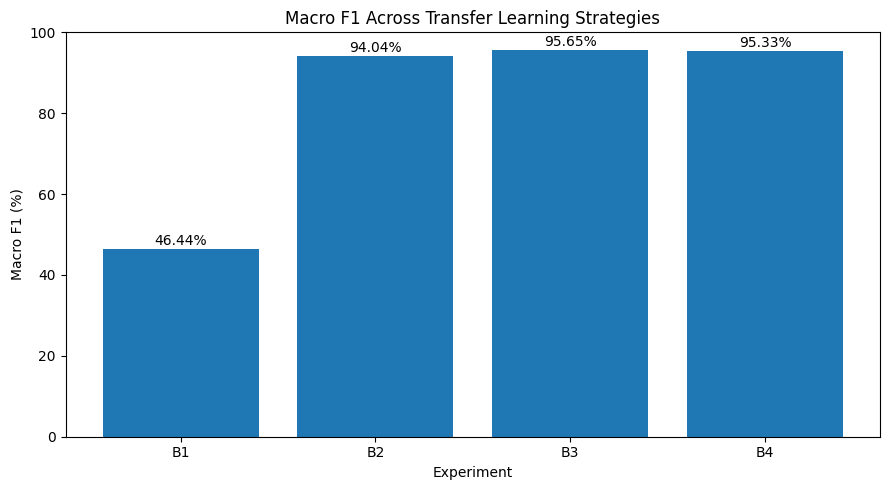

In [76]:
plt.figure(figsize=(9, 5))

plt.bar(
    final_results["experiment"],
    final_results["test_macro_f1"]
)

plt.xlabel("Experiment")
plt.ylabel("Macro F1 (%)")
plt.title("Macro F1 Across Transfer Learning Strategies")

plt.ylim(0, 100)

for i, value in enumerate(final_results["test_macro_f1"]):
    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

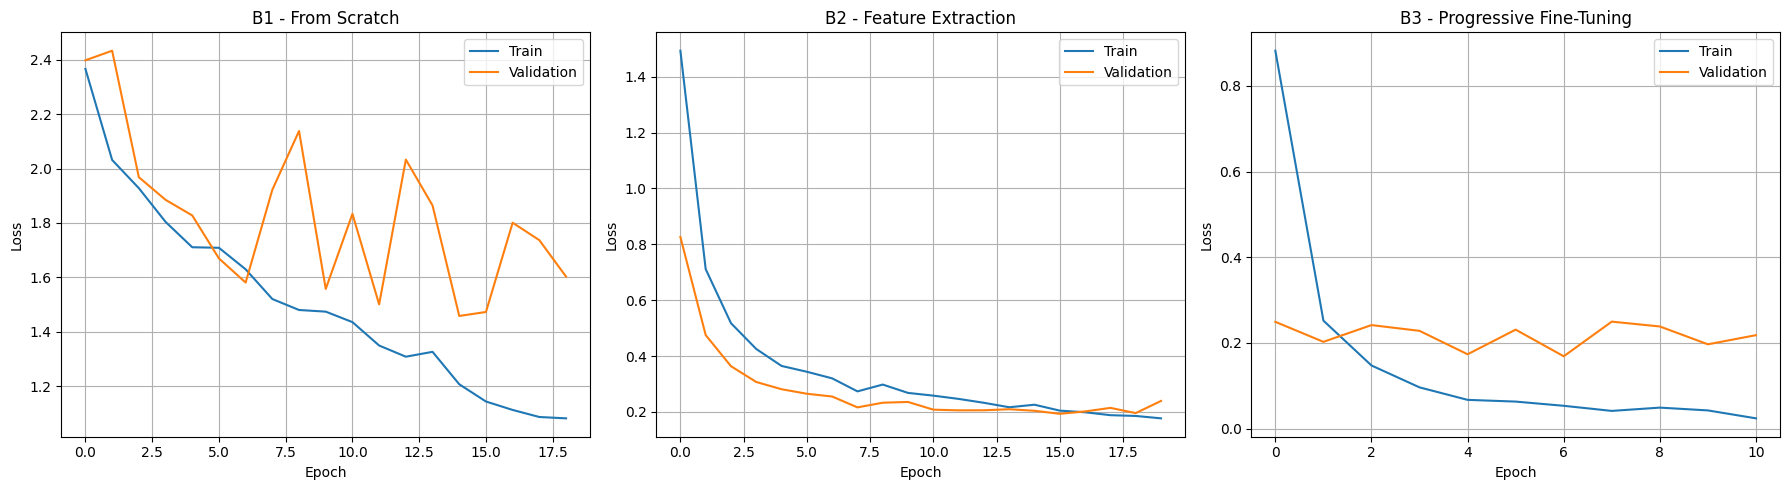

In [77]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

# B1
axes[0].plot(
    history_b1["train_loss"],
    label="Train"
)

axes[0].plot(
    history_b1["val_loss"],
    label="Validation"
)

axes[0].set_title("B1 - From Scratch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)


# B2
axes[1].plot(
    history_b2["train_loss"],
    label="Train"
)

axes[1].plot(
    history_b2["val_loss"],
    label="Validation"
)

axes[1].set_title("B2 - Feature Extraction")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)


# B3
axes[2].plot(
    history_b3["train_loss"],
    label="Train"
)

axes[2].plot(
    history_b3["val_loss"],
    label="Validation"
)

axes[2].set_title("B3 - Progressive Fine-Tuning")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Loss")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [78]:
print("=== KEY COMPARISONS ===")

print(
    f"B1 → B2 accuracy improvement: "
    f"{(b2_acc - b1_acc) * 100:.2f} percentage points"
)

print(
    f"B2 → B3 accuracy improvement: "
    f"{(b3_acc - b2_acc) * 100:.2f} percentage points"
)

print(
    f"B3 → B4 accuracy difference: "
    f"{(b4_acc - b3_acc) * 100:.2f} percentage points"
)

print()

print(
    f"B1 → B3 accuracy improvement: "
    f"{(b3_acc - b1_acc) * 100:.2f} percentage points"
)

print(
    f"B3 training time vs B1: "
    f"{training_time_b3 / training_time_b1:.2f}x"
)

print(
    f"B3 trainable parameters vs B1: "
    f"{trainable_params_b3 / trainable_params:.2f}x"
)

=== KEY COMPARISONS ===
B1 → B2 accuracy improvement: 46.64 percentage points
B2 → B3 accuracy improvement: 1.68 percentage points
B3 → B4 accuracy difference: -0.34 percentage points

B1 → B3 accuracy improvement: 48.32 percentage points
B3 training time vs B1: 0.54x
B3 trainable parameters vs B1: 0.75x
